
# TDMA Scheduling Discussion

This notebook starts from the per-user feasible configurations that were built in the earlier notebooks and asks the next question: once each user has a set of valid operating points, how can those users be scheduled together efficiently?

The walkthrough follows the same high-level flow used by the current code base:

1. define one scheduler-ready user batch,
2. build the per-user full-frame operating spaces,
3. resolve those spaces onto one shared TDMA window,
4. solve the exact joint schedule,
5. inspect why the chosen rows are efficient.

The single-user derivation is not repeated here. The focus is the joint scheduling step.



## 1. Notebook Scope

The reader is assumed to already know the single-user resource candidate space. Here the aim is to make the scheduler logic easy to follow. The notebook therefore keeps the code cells short and moves the plotting and formatting helpers into `helpers/tdma_scheduling_helpers.py`.

A small three-user batch is used throughout. It is large enough to show request reuse, slot coupling, and policy-dependent schedule choices, while still being practical to rerun.


In [1]:

import sys
import time
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").exists() and (candidate / "main.py").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"
HELPER_ROOT = REPO_ROOT / "helpers"

for path in (SRC_ROOT, HELPER_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from models import PASwitchPolicy, UserRequest

from multi_user_tdma_scheduler.api import (
    prepare_joint_schedule_problem,
    run_joint_schedule_search,
    run_multi_user_tdma_scheduler,
)

from single_user_parameter_space.api import build_batch_user_parameter_space

from helpers.tdma_scheduling_helpers import (
    build_user_requirements_table,
    build_pa_maps,
    build_policy_user_table,
    build_request_group_map,
    build_schedule_blocks,
    plot_3d_schedule,
    plot_full_frame_candidate_spaces,
    plot_mcs_heatmaps,
    plot_policy_comparison,
    plot_power_heatmaps,
    plot_selected_tdma_rows,
    plot_space_reduction,
    plot_user_batch_overview,
    summarize_batch_user_spaces,
    summarize_policy_result,
    summarize_prepared_problem,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25



## 2. Define One Scheduler Batch

The tutorial batch has three users:

- Users 1 and 2 share the same request.
- User 3 is farther away and asks for a lower average rate.

This is a useful teaching case because it shows two things at once. First, repeated requests can reuse one single-user solve. Second, the joint scheduler still has to decide how to share the common slot budget across all users.


tutorial_requests = (
    UserRequest(user_id=1, distance_m=150.0, required_rate_bps=20e6),
    UserRequest(user_id=2, distance_m=150.0, required_rate_bps=20e6),
    UserRequest(user_id=3, distance_m=350.0, required_rate_bps=30e6),
    UserRequest(user_id=4, distance_m=400.0, required_rate_bps=42e6),
)

expensive_tutorial_requests = (
    UserRequest(user_id=67, distance_m=300.0, required_rate_bps=142222222.2),
    UserRequest(user_id=164, distance_m=200.0, required_rate_bps=71111111.1),
    UserRequest(user_id=175, distance_m=200.0, required_rate_bps=47407407.4),
    UserRequest(user_id=230, distance_m=200.0, required_rate_bps=17777777.8),
    UserRequest(user_id=318, distance_m=200.0, required_rate_bps= 8888888.9),
    UserRequest(user_id=405, distance_m=125.0, required_rate_bps=17777777.8),
    UserRequest(user_id=406, distance_m=125.0, required_rate_bps= 8888888.9),
    UserRequest(user_id=410, distance_m=500.0, required_rate_bps= 8888888.9),
)

In [2]:

# Step 1: define the scheduler-ready users for one scheduling window.


tutorial_requests = (
    UserRequest(user_id=1, distance_m=150.0, required_rate_bps=20e6),
    UserRequest(user_id=2, distance_m=150.0, required_rate_bps=20e6),
    UserRequest(user_id=3, distance_m=350.0, required_rate_bps=30e6),
    UserRequest(user_id=4, distance_m=400.0, required_rate_bps=42e6),
)

user_table = build_user_requirements_table(tutorial_requests)
request_group_lookup = build_request_group_map(user_table)

user_batch_view = (
    user_table.assign(
        request_group=lambda df: df["user_id"].map(request_group_lookup),
        required_rate_mbps=lambda df: df["required_rate_bps"] / 1e6,
    )[
        ["user_id", "request_group", "distance_m", "required_rate_mbps"]
    ]
    .rename(
        columns={
            "user_id": "user id",
            "request_group": "request group",
            "distance_m": "distance (m)",
            "required_rate_mbps": "required average rate (Mbps)",
        }
    )
)

display(user_batch_view)


,user id,request group,distance (m),required average rate (Mbps)
0,1,1,150.0,20.0
1,2,1,150.0,20.0
2,3,2,350.0,30.0
3,4,3,400.0,42.0


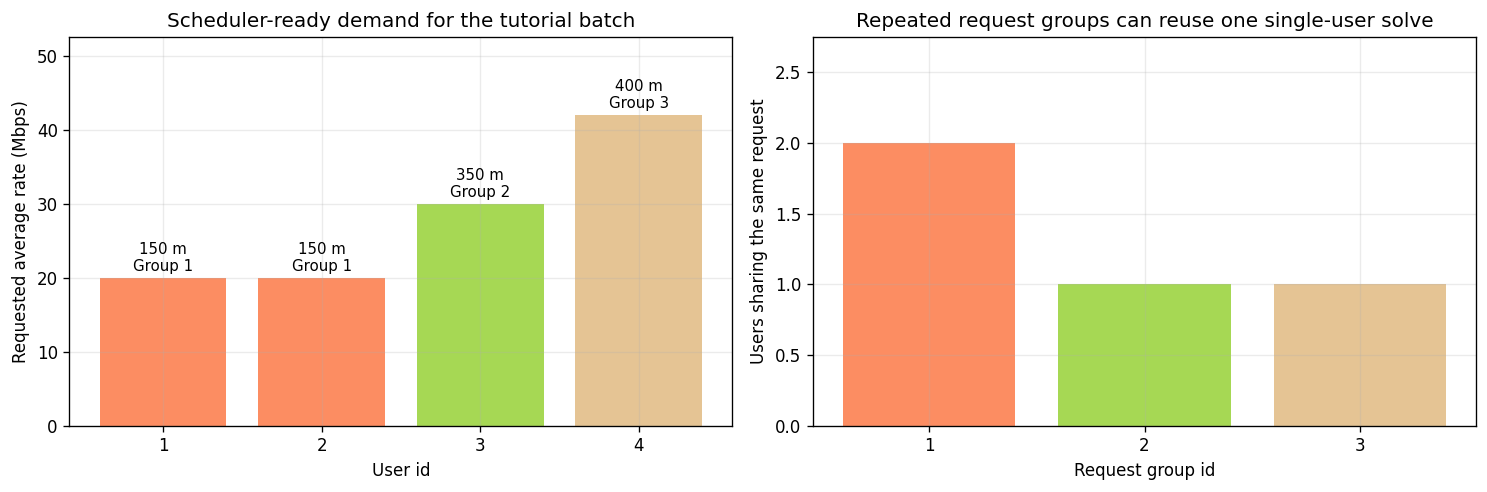

In [3]:
plot_user_batch_overview(user_table, request_group_lookup)


## 3. Build the Batch Single-User Parameter Space

The scheduler does not search directly over raw link states. It starts from the batch single-user artifact returned by `build_batch_user_parameter_space(user_table)`.

For each user, that artifact contains the full-frame active operating points that survived the single-user feasibility checks. Those are the rows the TDMA scheduler is later allowed to time-share.


In [4]:

# Step 2: build the full-frame operating spaces for each user.
batch_start = time.perf_counter()
batch_space = build_batch_user_parameter_space(user_table)
batch_build_s = time.perf_counter() - batch_start

pa_table, pa_label_map, pa_color_map = build_pa_maps(batch_space)
batch_user_space_summary = summarize_batch_user_spaces(
    batch_space,
    user_table,
    pa_label_map,
    request_group_lookup,
)

print(
    f"Built the batch single-user space in {batch_build_s:.2f} s. "
    f"The shared frame has {int(batch_space.frame_n_slots)} slots, "
    f"{int(batch_space.n_tx_chains)} TX chains, and {len(batch_space.pa_catalog)} PA models."
)

pa_overview_view = pa_table[
    ["pa_id", "scenario_label", "p_max_w", "p_idle_w", "eta_max"]
].rename(
    columns={
        "pa_id": "pa id",
        "scenario_label": "PA label",
        "p_max_w": "max RF output power (W)",
        "p_idle_w": "idle power per chain (W)",
        "eta_max": "peak efficiency",
    }
)

display(pa_overview_view)


Built the batch single-user space in 287.07 s. The shared frame has 20 slots, 4 TX chains, and 2 PA models.


,pa id,PA label,max RF output power (W),idle power per chain (W),peak efficiency
0,0,8W PA,7.928899,3.8400,0.418165
1,1,4W PA,1.784671,0.4215,0.352236



## 4. Full-Frame Candidate Spaces Before TDMA Quantization

Each point below is one full-frame active row from `batch_space.user_parameter_spaces[user_id]`. At this stage, the scheduler has not yet decided how many slots each user should occupy. It only knows what each user can do if that user stays active for the whole frame.

The dashed line marks the required average rate for that user. The star marks the cheapest feasible row inside each PA family.


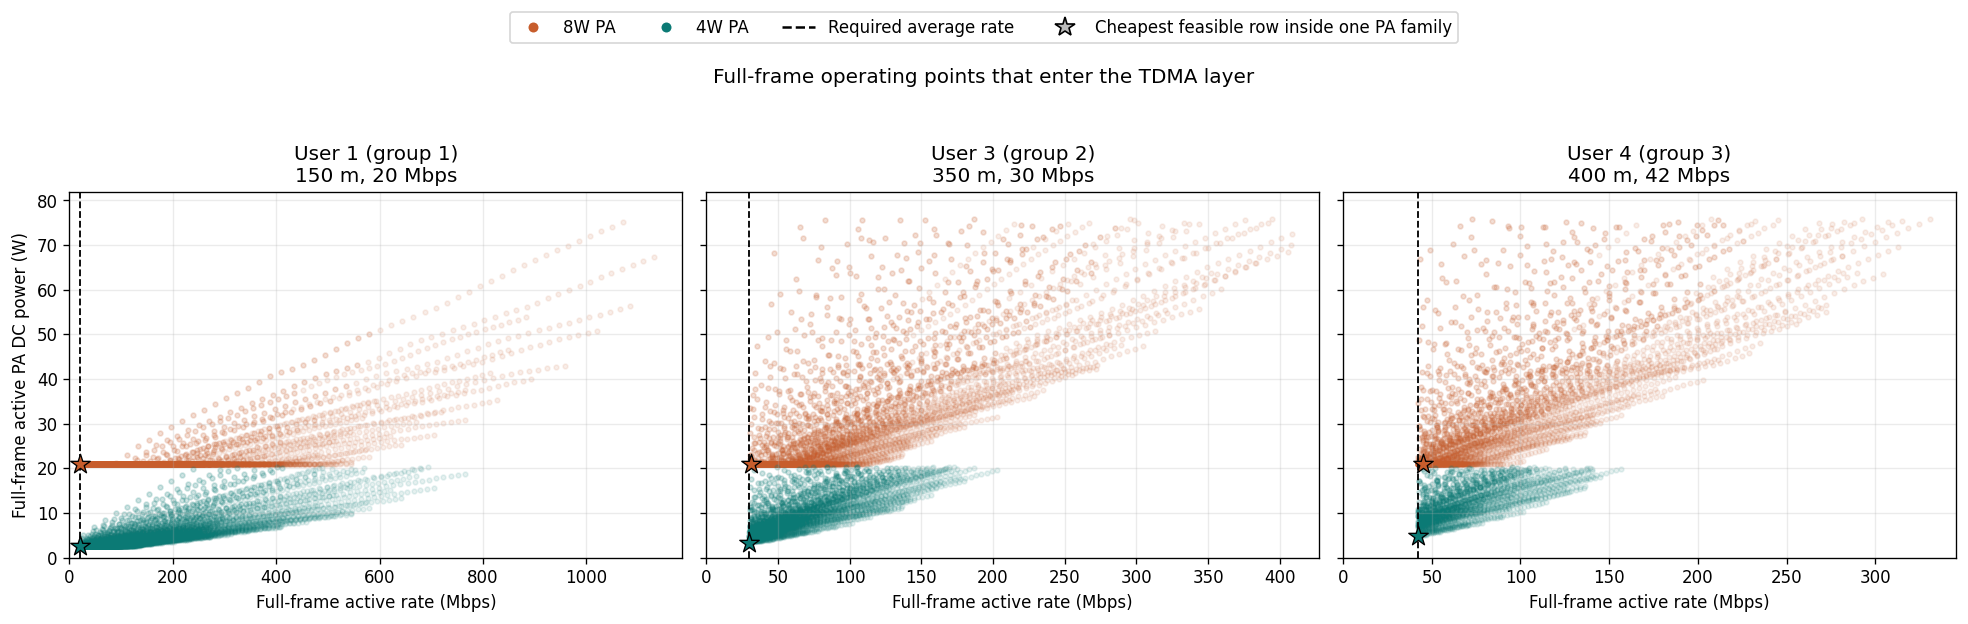

In [5]:
plot_full_frame_candidate_spaces(batch_space, user_table, request_group_lookup, pa_color_map, pa_label_map)


For this batch, the main point is already visible before any joint search begins. Near the demand line for each user, the cheaper feasible rows are still on the 4 W PA. The multi-user scheduler therefore does not start from two equally attractive PA families. It starts from a candidate set in which one family is already more competitive.



## 5. Resolve the Full-Frame Spaces Onto One TDMA Window

The helper `run_multi_user_tdma_scheduler(...)` performs this internally, but the notebook stops at the intermediate public API so the transformation can be inspected:

1. `prepare_joint_schedule_problem(...)`
2. `run_joint_schedule_search(...)`

This step converts full-frame rows into exact TDMA candidate rows on one shared slot window and prunes dominated rows.


In [6]:

# Step 3: resolve the full-frame rows onto the shared TDMA window.
problem = prepare_joint_schedule_problem(batch_space)
main_style_standby_result = run_multi_user_tdma_scheduler(
    batch_space,
    switch_policy=PASwitchPolicy.STANDBY,
)

prepared_problem_summary = summarize_prepared_problem(problem, user_table, pa_label_map)
slot_lower_bound = int(
    sum(
        problem.user_candidate_spaces[int(user_id)]["n_slots"].min()
        for user_id in user_table["user_id"].astype(int)
    )
)

print(
    f"The resolved window spans {int(problem.window_n_frames)} frame(s) and {int(problem.window_n_slots)} slot(s). "
    f"The per-user minimum adds up to {slot_lower_bound} slots, which leaves "
    f"{int(problem.window_n_slots - slot_lower_bound)} slot(s) of slack for the joint search."
)


The resolved window spans 1 frame(s) and 20 slot(s). The per-user minimum adds up to 7 slots, which leaves 13 slot(s) of slack for the joint search.


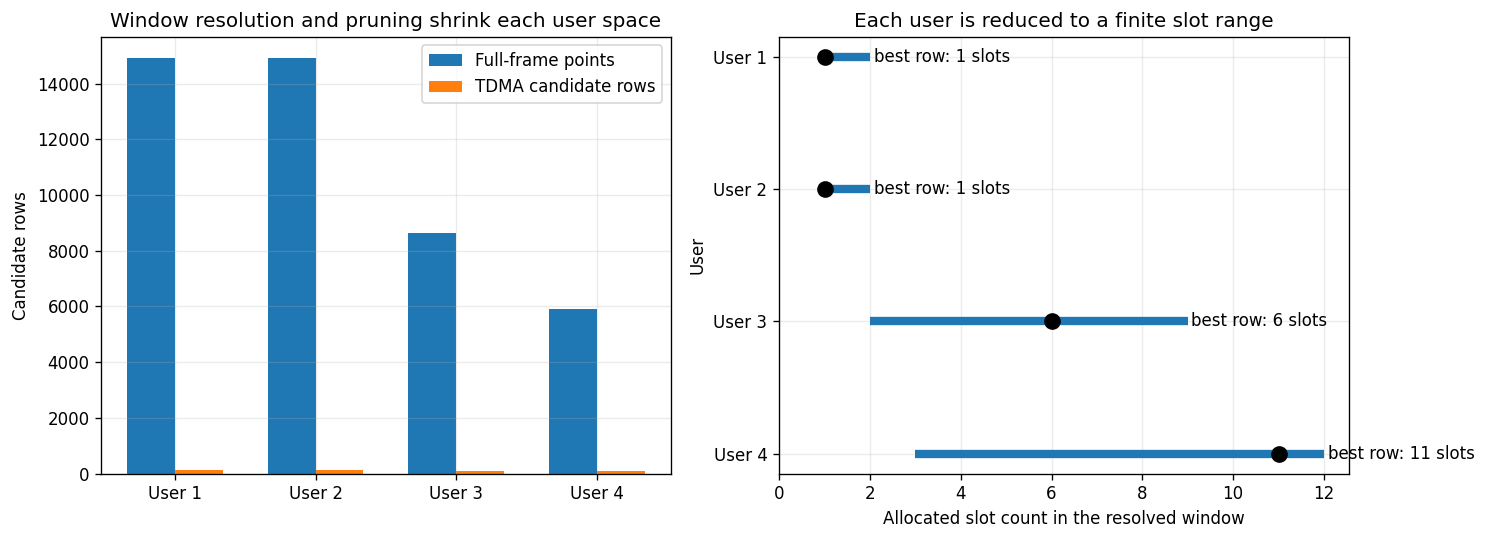

In [7]:
plot_space_reduction(batch_user_space_summary, prepared_problem_summary)


The left plot shows the effect of quantization and pruning. The right plot shows what remains after that reduction: for each user, the joint search only needs to choose a finite slot count and one row inside that slot count.



## 6. Solve the Exact Joint Scheduler Under Both PA Switch Policies

The same prepared problem is now solved twice:

- `standby`: every installed PA bank remains powered, so inactive time still draws that bank's idle power,
- `hard_off`: inactive time on every PA bank is treated as zero power.

Nothing else changes. The user demands, the candidate spaces, and the slot window are the same in both runs.


In [8]:

# Step 4: solve the same TDMA problem under both PA switch policies.
policy_order = [PASwitchPolicy.STANDBY.value, PASwitchPolicy.HARD_OFF.value]
policy_results = {}
policy_summary_rows = []
policy_user_tables = []

for policy in PASwitchPolicy:
    solve_start = time.perf_counter()
    result = run_joint_schedule_search(problem, switch_policy=policy)
    result.search_stats["solve_time_s"] = float(time.perf_counter() - solve_start)
    policy_results[policy.value] = result
    policy_summary_rows.append(
        summarize_policy_result(policy.value, result, user_table, pa_label_map)
    )
    policy_user_tables.append(
        build_policy_user_table(policy.value, result, user_table, pa_label_map)
    )

policy_summary_view = (
    pd.DataFrame(policy_summary_rows)
    .assign(
        switch_policy=lambda df: pd.Categorical(
            df["switch_policy"],
            categories=policy_order,
            ordered=True,
        )
    )
    .sort_values("switch_policy")
    .reset_index(drop=True)
)

schedule_choice_view = (
    pd.concat(policy_user_tables, ignore_index=True)
    .assign(
        switch_policy=lambda df: pd.Categorical(
            df["switch_policy"],
            categories=policy_order,
            ordered=True,
        )
    )
    .sort_values(["switch_policy", "user_id"])
    .reset_index(drop=True)
)

standby_walkthrough_result = policy_results[PASwitchPolicy.STANDBY.value]
assert np.isclose(
    main_style_standby_result.best_schedule["schedule_p_dc_total_avg_frame_w"],
    standby_walkthrough_result.best_schedule["schedule_p_dc_total_avg_frame_w"],
)
assert int(main_style_standby_result.best_schedule["slot_total"]) == int(
    standby_walkthrough_result.best_schedule["slot_total"]
)

print(
    "The explicit two-step walkthrough matches the same public path used by main.py: "
    "build_batch_user_parameter_space(...) -> run_multi_user_tdma_scheduler(...)."
)

display(
    policy_summary_view.rename(
        columns={
            "switch_policy": "switch policy",
            "solve_time_s": "solve time (s)",
            "total_power_w": "total PA DC power (W)",
            "active_power_w": "active contribution (W)",
            "inactive_power_w": "inactive contribution (W)",
            "slot_total": "used slots",
            "unused_slots": "unused slots",
            "total_rate_mbps": "achieved sum rate (Mbps)",
            "requested_rate_mbps": "requested sum rate (Mbps)",
            "used_pas": "used PAs",
        }
    )
)


The explicit two-step walkthrough matches the same public path used by main.py: build_batch_user_parameter_space(...) -> run_multi_user_tdma_scheduler(...).


,switch policy,solve time (s),total PA DC power (W),active contribution (W),inactive contribution (W),used slots,unused slots,achieved sum rate (Mbps),requested sum rate (Mbps),used PAs
0,standby,0.037383,22.654337,7.294337,1.536000e+01,20,0,115.452647,112.0,4W PA
1,hard_off,0.022143,7.237077,7.237077,-8.881784e-16,19,1,113.259139,112.0,4W PA



## 7. Why the Two Policies Pick Different Rows

The first figure separates active and inactive power. The second figure shows the direct scheduling consequence for each user.

When standby keeps every installed PA bank alive, the scheduler starts from a higher idle baseline and can benefit from using a bank that would otherwise sit idle. When that inactive penalty disappears under `hard_off`, the search can move toward fewer active slots and lower active-only power.


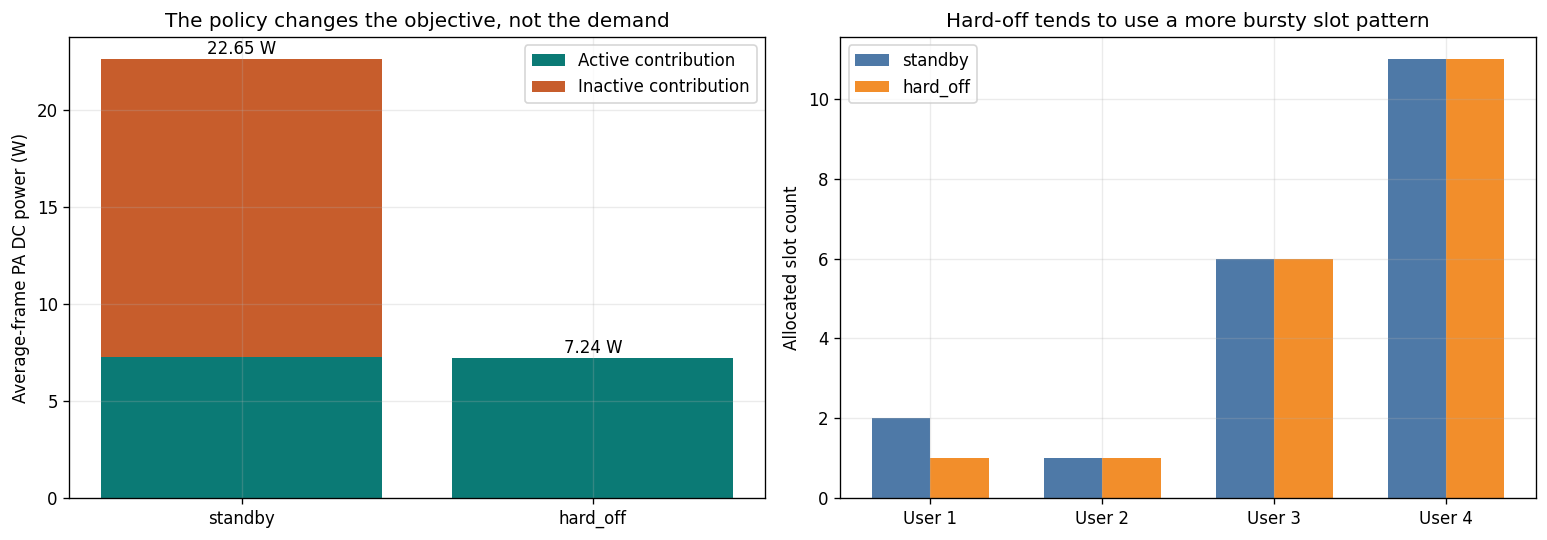

In [9]:
plot_policy_comparison(policy_summary_view, schedule_choice_view, policy_order)


For this batch, both policies still choose the 4 W PA. The difference is temporal rather than architectural. The policy changes which row is best inside the same user-level candidate space.



## 8. Selected Rows on Each User's TDMA Candidate Space

The next figure shows the pruned TDMA candidate cloud for each user. The selected row under each switch policy is placed on top of that cloud. This is the clearest point to see that the final search is choosing among already-pruned, slot-resolved rows rather than among the original dense full-frame points.


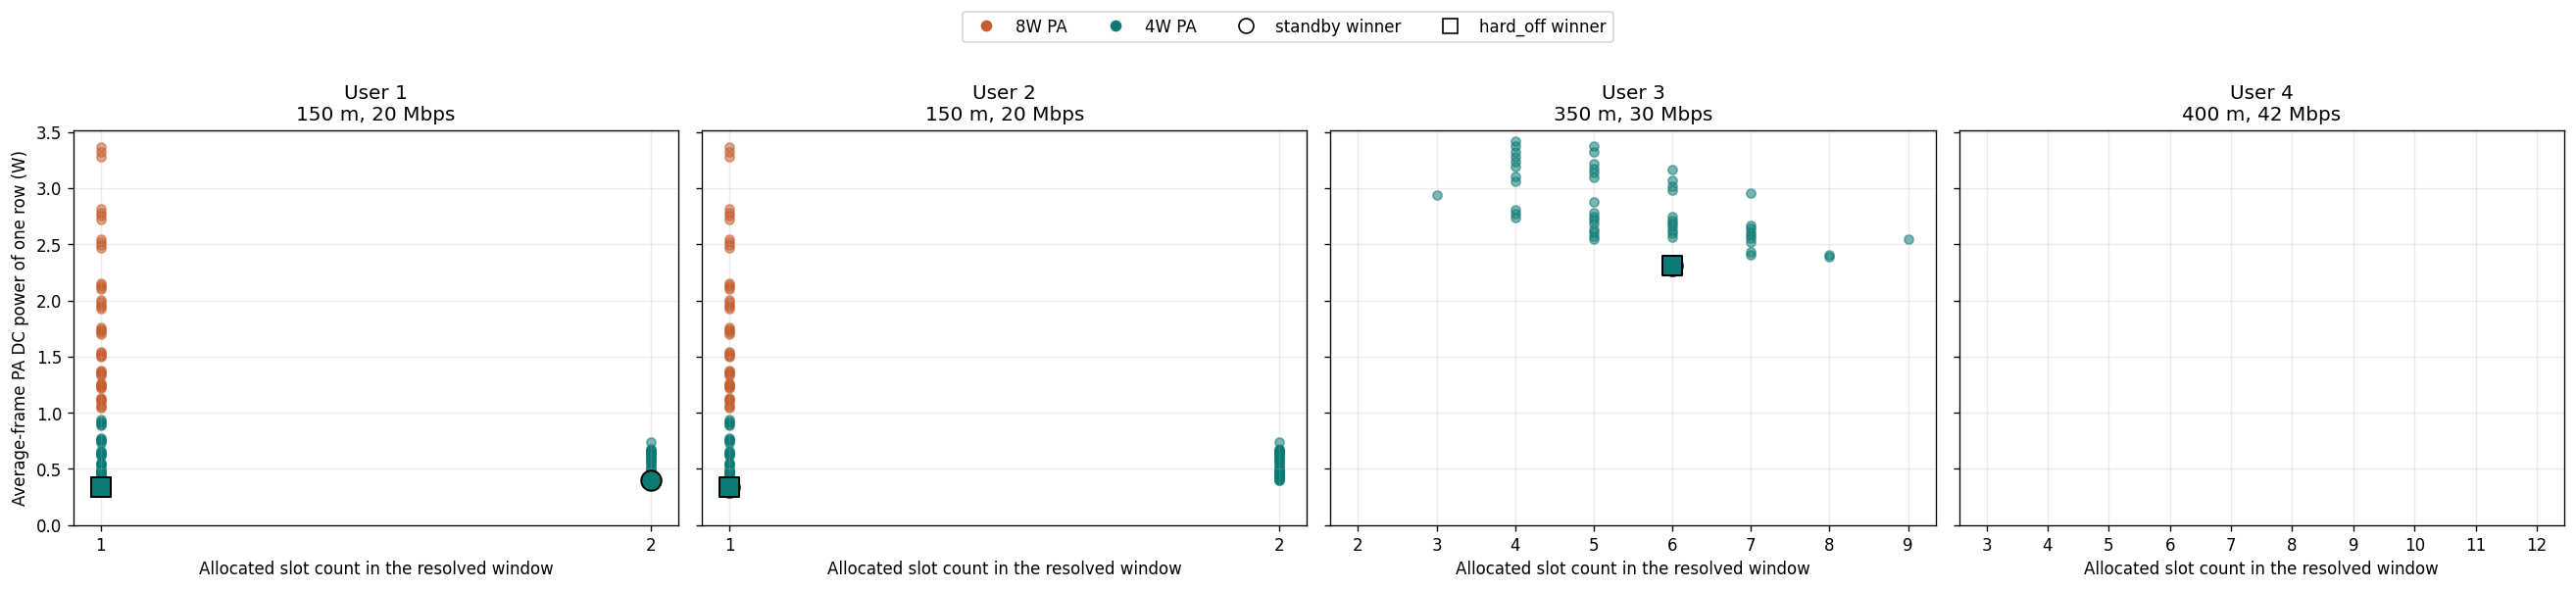

In [15]:
plot_selected_tdma_rows(problem, user_table, policy_results, schedule_choice_view, pa_color_map, pa_label_map)


## 9. Schedule Geometry on the Resolved Resource Grid

The scheduler chooses one row per user. It does not optimize a detailed slot ordering. Once the slot counts are fixed, any non-overlapping packing of those rows is equivalent. The visualizations below therefore use a simple sequential packing by user id.


In [11]:

# Step 5: build one simple geometric view of the chosen rows.
allocation_views = {
    policy_name: build_schedule_blocks(result.best_schedule, problem, pa_label_map)
    for policy_name, result in policy_results.items()
}


The first plot shows one valid 3D packing of the standby solution across slots, PRBs, and spatial layers.

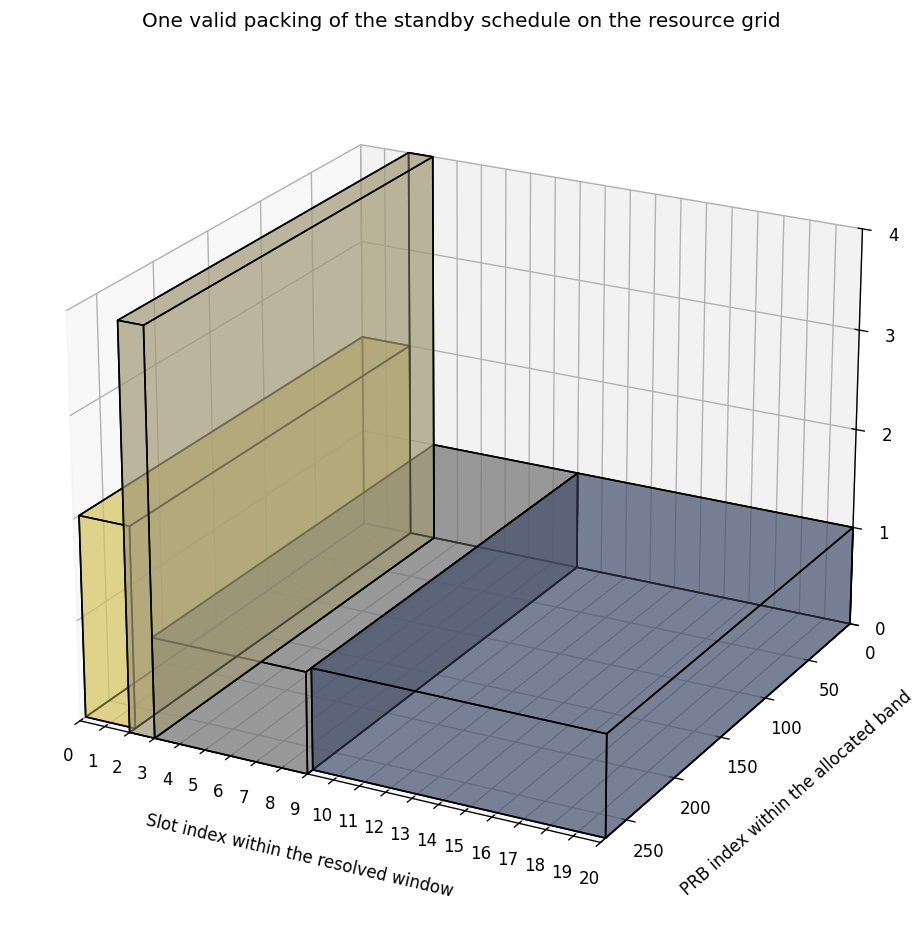

In [12]:


plot_3d_schedule(allocation_views[PASwitchPolicy.STANDBY.value], problem)

The next heatmaps keep the same packing convention but compare the two policy outcomes directly.

c:\Users\henry\Documents\Masters Thesis\code\notebooks\helpers\tdma_scheduling_helpers.py:822: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 0.9, 1))


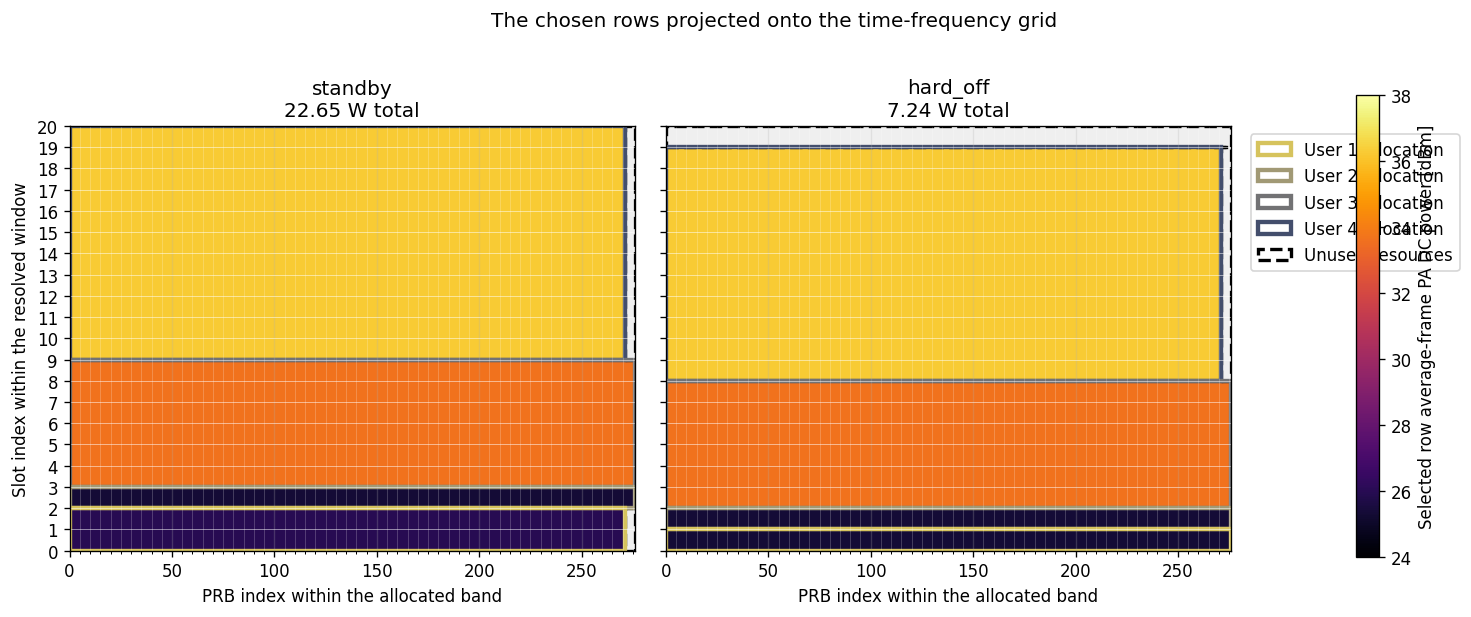

In [13]:
plot_power_heatmaps(allocation_views, policy_order, policy_summary_view)

c:\Users\henry\Documents\Masters Thesis\code\notebooks\helpers\tdma_scheduling_helpers.py:873: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 0.9, 1))


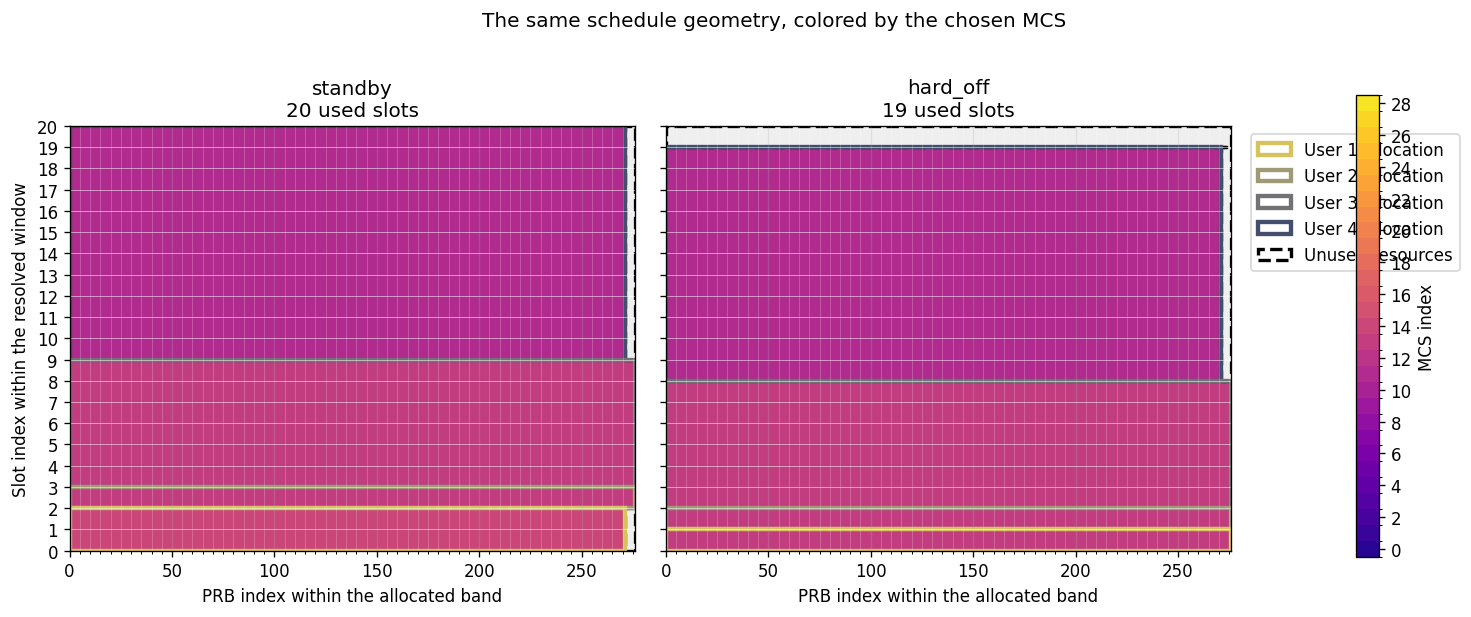

In [14]:
plot_mcs_heatmaps(allocation_views, policy_order, policy_summary_view)


## 10. Takeaways

This notebook now focuses on the scheduler question rather than on helper code:

- the single-user layer builds the feasible full-frame spaces,
- the TDMA preparation step resolves those spaces onto one shared slot window,
- the exact search chooses one row per user under a shared objective,
- the PA switch policy changes which rows are cheapest.

For this batch, the corrected standby model no longer stays on the 4 W PA alone. Because the 8 W bank still draws idle power even when it is not selected, that standby cost is already being paid and the scheduler can reduce total power by mixing 8 W and 4 W rows. Under `hard_off`, the inactive penalty disappears and the optimizer returns to the cheaper all-4 W active solution.

A useful next check is to increase user 3's required rate or move user 3 farther away. That makes it easier to see when the 8 W PA starts to become competitive in the joint schedule.
